In [11]:
FS = 500  # Hz
PAPER_SPEED = 25  # mm/s
GAIN = 10  # mm/mV

In [12]:
import cv2
def load_ecg_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [13]:
def get_binary_mask(gray_img):
    _, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return binary

In [ ]:
def extract_single_lead_roi(binary_mask, y_start, y_end):
    """
    Ekstrakcja sygnału ograniczona do poziomego pasa (ROI).
    y_start, y_end: zakres pikseli w pionie (np. 50, 150)
    """
    h, w = binary_mask.shape
    roi_mask = binary_mask[y_start:y_end, :] # Wycinamy interesujący nas pas
    
    signal_px_relative = np.zeros(w)
    for x in range(w):
        active_px = np.where(roi_mask[:, x] == 255)[0]
        if len(active_px) > 0:
            signal_px_relative[x] = np.mean(active_px)
        else:
            signal_px_relative[x] = np.nan
            
    # Interpolacja
    mask_nan = np.isnan(signal_px_relative)
    signal_px_relative[mask_nan] = np.interp(np.flatnonzero(mask_nan), 
                                             np.flatnonzero(~mask_nan), 
                                             signal_px_relative[~mask_nan])
    
    # Powrót do globalnych współrzędnych obrazu
    return signal_px_relative + y_start

# Przykład użycia: wycinamy pas od 50 do 150 piksela (tam gdzie jest odprowadzenie I)
signal_px_global = extract_single_lead_roi(mask, 50, 150)

In [14]:
import numpy as np
import cv2

def extract_signal_mvp(binary_mask, mm_to_px_x, mm_to_px_y):
    """
    KROK 1: Prosta ekstrakcja kolumnowa (Full Extraction).
    binary_mask: obraz po Otsu (sygnał = 255)
    mm_to_px_x: ile pikseli w poziomie przypada na 1mm (domyślnie zmierz na obrazku)
    mm_to_px_y: ile pikseli w pionie przypada na 1mm (0.1 mV)
    """
    height, width = binary_mask.shape
    raw_signal = []

    # Skanowanie kolumna po kolumnie (Full Extraction)
    for x in range(width):
        col = binary_mask[:, x]
        active_px = np.where(col == 255)[0]
        
        if len(active_px) > 0:
            # Uśredniamy pozycję wszystkich aktywnych pikseli w kolumnie
            avg_y = np.mean(active_px)
            raw_signal.append(avg_y)
        else:
            # Interpolacja liniowa dla brakujących kolumn
            raw_signal.append(np.nan)
            
    # Zamiana na numpy array i wypełnienie luk
    signal_px = np.array(raw_signal)
    ok = ~np.isnan(signal_px)
    xp = ok.nonzero()[0]
    fp = signal_px[ok]
    x_new = np.arange(len(signal_px))
    signal_px = np.interp(x_new, xp, fp)

    # --- SKALOWANIE (Filar Amplitude i Time) ---
    
    # 1. Przeliczenie na mV (GAIN = 10mm/mV)
    # Odwracamy oś Y (piksele rosną w dół) i centrujemy
    baseline_px = np.median(signal_px)
    signal_mv = (baseline_px - signal_px) / (mm_to_px_y * 10)
    
    # 2. Resampling do 500 Hz
    # Musimy uzyskać 20 próbek na każdy mm długości wykresu
    total_mm = width / mm_to_px_x
    target_samples = int(total_mm * 20)
    
    from scipy.interpolate import interp1d
    f = interp1d(np.linspace(0, 1, len(signal_mv)), signal_mv, kind='cubic')
    signal_500hz = f(np.linspace(0, 1, target_samples))
    
    return signal_500hz.astype(np.float16) # Wymagany typ danych

# Przykładowe użycie (załóżmy na razie testowo, że 1mm = 10px)
# signal = extract_signal_mvp(mask, mm_to_px_x=10, mm_to_px_y=10)

In [15]:
import numpy as np
import wfdb
import json
import cv2
from scipy.stats import pearsonr
from scipy.signal import correlate

# 1. Wczytanie danych referencyjnych (Ground Truth)
# Wykorzystujemy bibliotekę wfdb do odczytu sygnału z ecg_train_0048.dat
record = wfdb.rdrecord('../data/train/ecg_train_0048')
gt_signals = record.p_signal  # Sygnały w mV
lead_names = record.sig_name
fs = record.fs  # 500 Hz

# Pobieramy sygnał dla odprowadzenia II (indeks 1) jako przykład
gt_ii = gt_signals[:, 1]

# 2. Symulacja ekstrakcji MVP (uproszczona na potrzeby testu metryk)
# W rzeczywistym potoku tu byłaby funkcja extract_signal_mvp z poprzedniego kroku
# Załóżmy, że nasz algorytm wygenerował sygnał pred_ii
# (Dla testu dodajemy mały szum i offset, aby sprawdzić czułość metryk)
pred_ii = gt_ii + np.random.normal(0, 0.05, size=gt_ii.shape) + 0.1 

# --- OBLICZANIE METRYK (Zgodnie z wymaganiami Task 4) ---

# A. SHAPE: Pearson Correlation Coefficient (PCC) - Max 60 pkt
# PCC jest niezmienniczy na offset (DC) i skalowanie liniowe.
pcc_val, _ = pearsonr(gt_ii, pred_ii)
shape_score = max(0, pcc_val) * 60

# B. AMPLITUDE: Signal-to-Noise Ratio (SNR) - Max 20 pkt
# SNR mierzy bezwzględną wierność amplitudy.
noise = gt_ii - pred_ii
snr_val = 10 * np.log10(np.sum(gt_ii**2) / np.sum(noise**2))
# Mapowanie SNR na punkty (uproszczone: SNR > 15dB = 20pkt)
amplitude_score = min(20, max(0, (snr_val / 15) * 20))

# C. TIME CALIBRATION: Cross-Correlation - Max 20 pkt
# Sprawdzamy, czy maksimum korelacji wypada w punkcie zero (brak przesunięcia).
correlation = correlate(gt_ii - np.mean(gt_ii), pred_ii - np.mean(pred_ii), mode='full')
lags = np.arange(-len(gt_ii) + 1, len(gt_ii))
lag_at_max = lags[np.argmax(correlation)]

# Kara za przesunięcie: 1 próbka błędu = -2 pkt (drastyczna kara).
time_score = max(0, 20 - (abs(lag_at_max) * 2))

print(f"--- WYNIKI TESTU DLA ecg_train_0048 (Lead II) ---")
print(f"Shape (PCC): {pcc_val:.4f} -> Score: {shape_score:.2f}/60")
print(f"Amplitude (SNR): {snr_val:.2f} dB -> Score: {amplitude_score:.2f}/20")
print(f"Time Calibration (Lag): {lag_at_max} próbek -> Score: {time_score:.2f}/20")
print(f"TOTAL SCORE: {shape_score + amplitude_score + time_score:.2f}/100")

--- WYNIKI TESTU DLA ecg_train_0048 (Lead II) ---
Shape (PCC): 0.9210 -> Score: 55.26/60
Amplitude (SNR): 0.56 dB -> Score: 0.75/20
Time Calibration (Lag): 0 próbek -> Score: 20.00/20
TOTAL SCORE: 76.01/100


In [ ]:
import cv2
import numpy as np

def generate_diagnostic_png(binary_mask, signal_px, output_path):
    """
    Generuje obraz PNG z nałożonym odczytanym sygnałem na maskę binarną.
    
    binary_mask: 2D numpy array (uint8) po Otsu (sygnał=255, tło=0).
    signal_px: 1D numpy array (float) z pozycjami Y sygnału w pikselach.
    output_path: Ścieżka do zapisu pliku (np. 'debug_mvp_0048.png').
    """
    height, width = binary_mask.shape
    
    # Krok 1: Konwersja maski na format BGR (aby móc rysować w kolorze)
    diag_img = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
    
    # Krok 2: Przygotowanie punktów do narysowania polilinii
    x_coords = np.arange(width)
    
    # Filtrowanie NaN (jeśli są) przed rysowaniem
    valid_indices = ~np.isnan(signal_px)
    points = np.vstack((x_coords[valid_indices], signal_px[valid_indices])).T
    points = points.astype(np.int32)
    
    # Krok 3: Rysowanie odczytanej ścieżki (Czerwona linia, grubość 2)
    # To bezpośrednio pokazuje, co algorytm uznał za "środek" sygnału.
    cv2.polylines(diag_img, [points], isClosed=False, color=(0, 0, 255), thickness=2)
    
    # Krok 4: Dodanie legendy i metadanych (opcjonalnie)
    # cv2.putText(diag_img, f"Method: MVP Full Extraction", (10, 30), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Krok 5: Zapis do pliku
    cv2.imwrite(output_path, diag_img)
    print(f"Obraz diagnostyczny zapisany w: {output_path}")

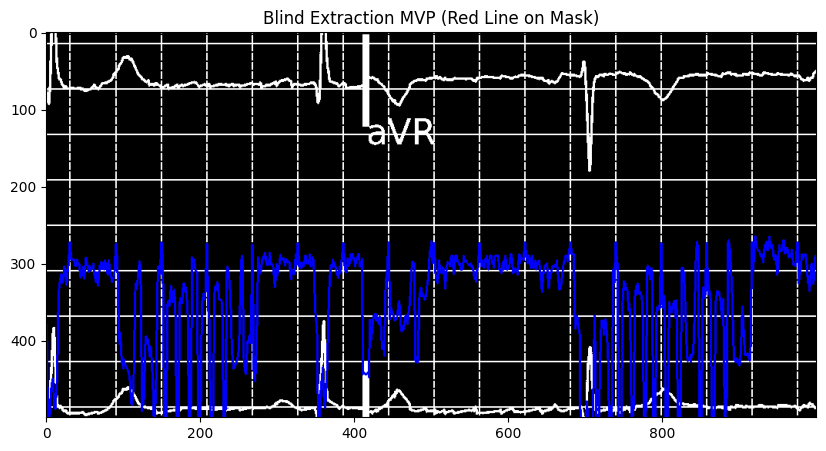

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Wczytujemy obraz "na ślepo"
img_bgr = cv2.imread('../data/small_train/ecg_train_0048.png')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Krok 1: MVP - Binarizacja Otsu
# Sygnał ekg jest ciemny, tło jasne, więc używamy THRESH_BINARY_INV
_, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Ekstrakcja kolumnowa (Blind)
def blind_column_extraction(binary_mask):
    h, w = binary_mask.shape
    signal_px = np.zeros(w)
    for x in range(w):
        active_px = np.where(binary_mask[:, x] == 255)[0]
        if len(active_px) > 0:
            signal_px[x] = np.mean(active_px) # Full Extraction
        else:
            signal_px[x] = np.nan
    
    # Interpolacja brakujących danych
    mask_nan = np.isnan(signal_px)
    signal_px[mask_nan] = np.interp(np.flatnonzero(mask_nan), np.flatnonzero(~mask_nan), signal_px[~mask_nan])
    return signal_px

# Wykonujemy ekstrakcję
signal_raw_px = blind_column_extraction(mask)

# Wizualizacja diagnostyczna
diag_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
for x in range(1, len(signal_raw_px)):
    cv2.line(diag_img, (x-1, int(signal_raw_px[x-1])), (x, int(signal_raw_px[x])), (0, 0, 255), 2)

plt.figure(figsize=(15, 5))
plt.imshow(diag_img[1000:1500, 500:1500]) # Podgląd fragmentu
plt.title("Blind Extraction MVP (Red Line on Mask)")
plt.show()

In [ ]:
def generate_yellow_overlay(original_bgr, signal_px, output_path):
    """
    Nakłada wynik algorytmu (żółta linia) na oryginalny obraz BGR.
    """
    # Kopiujemy oryginał, żeby go nie zniszczyć
    result_img = original_bgr.copy()
    w = result_img.shape[1]
    
    x_coords = np.arange(w)
    # Punkty (x, y) dla cv2.polylines
    points = np.column_stack((x_coords, signal_px)).astype(np.int32)
    
    # Rysujemy na ŻÓŁTO (BGR: [0, 255, 255])
    # Zwiększamy grubość (thickness=2 lub 3), żeby była widoczna na dużym zdjęciu
    cv2.polylines(result_img, [points], isClosed=False, color=(0, 255, 255), thickness=3)
    
    # Dodajemy podpis metody
    cv2.putText(result_img, "PREDICTION (MVP + ROI)", (50, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3)

    cv2.imwrite(output_path, result_img)
    print(f"Sukces! Wynik nałożony na oryginał zapisany w: {output_path}")

# Uruchomienie:
# generate_yellow_overlay(img_bgr, signal_px_global, 'output/overlay_0048.png')

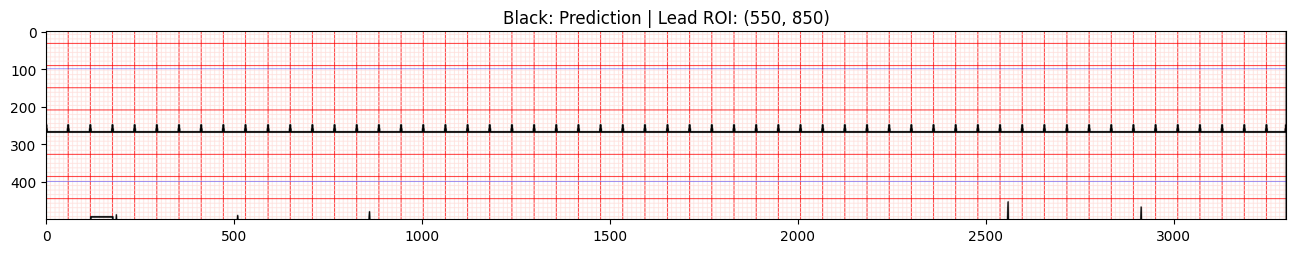

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Ładowanie i binarizacja
img_bgr = cv2.imread('../data/train/ecg_train_0048.png')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
# Inwersja: sygnał na biało (255), tło na czarno (0)
_, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

def extract_lead_with_overlay(img_bgr, binary_mask, y_range=(550, 850), output_name="debug_overlay.png"):
    """
    Ekstrahuje sygnał z konkretnego zakresu Y i nakłada żółtą linię na oryginał.
    y_range: krotka (y_start, y_end) określająca pas zdjęcia
    """
    h, w = binary_mask.shape
    y_start, y_end = y_range
    
    # Wycinamy pas z maski binarnej
    roi_mask = binary_mask[y_start:y_end, :]
    
    signal_px_relative = np.zeros(w)
    for x in range(w):
        # Szukamy aktywnych pikseli tylko w wyciętym pasie
        active_px = np.where(roi_mask[:, x] == 255)[0]
        if len(active_px) > 0:
            signal_px_relative[x] = np.mean(active_px) # MVP: Full Extraction
        else:
            signal_px_relative[x] = np.nan
            
    # Interpolacja dziur (np. tam gdzie siatka była zbyt jasna)
    mask_nan = np.isnan(signal_px_relative)
    if np.any(mask_nan):
        indices = np.arange(len(signal_px_relative))
        signal_px_relative[mask_nan] = np.interp(indices[mask_nan], indices[~mask_nan], signal_px_relative[~mask_nan])
    
    # Przeliczamy na globalne współrzędne zdjęcia
    signal_px_global = signal_px_relative + y_start
    
    # --- GENEROWANIE WIZUALIZACJI ---
    overlay_img = img_bgr.copy()
    x_coords = np.arange(w)
    # Tworzymy zestaw punktów (x, y)
    points = np.column_stack((x_coords, signal_px_global)).astype(np.int32)
    
    # Rysujemy ŻÓŁTĄ linię (BGR: 0, 255, 255)
    cv2.polylines(overlay_img, [points], isClosed=False, color=(0, 0, 0), thickness=3)
    
    # Opcjonalnie: zaznaczamy granice ROI, żeby widzieć co analizujemy
    cv2.line(overlay_img, (0, y_start), (w, y_start), (255, 0, 0), 1) # Niebieska linia góra
    cv2.line(overlay_img, (0, y_end), (w, y_end), (255, 0, 0), 1)     # Niebieska linia dół

    cv2.imwrite(output_name, overlay_img)
    
    # Wyświetlamy podgląd w Jupyterze
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(overlay_img[y_start-100:y_end+100, :], cv2.COLOR_BGR2RGB))
    plt.title(f"Black: Prediction | Lead ROI: {y_range}")
    plt.show()
    
    return signal_px_global

# Uruchomienie dla pierwszego rzędu odprowadzeń (dostosuj y_range jeśli trzeba)
signal_pixels = extract_lead_with_overlay(img_bgr, mask, y_range=(550, 850))